<a href="https://colab.research.google.com/github/stymo/notebooks/blob/main/Chicago_Nighthawk_Project_Occupancy_Modeling_Analysis_Story_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Nighthawk Project Occupancy Modeling Analysis


For the last 3 years, I have participated in the [Chicago Nighthawk Project](https://www.chicagobirder.org/chicago-nighthawk-project), a citzen science project that monitors the urban population of Common Nighthawks (*Chordeiles minor*). Recently, I attented a talk presented by Timm Haucke on *occupancy modeling* using his sofware [biolith](https://timm.haucke.xyz/biolith/) at the International Conservation Technology Conference in Lima, Peru. Though the terminology was new to me, I immediately realized that it expressed the logic behind the Nighthawk Project [protocol](https://static1.squarespace.com/static/580d29af8419c2606f6f60ed/t/66255a82d2a51f2445732852/1713724034744/2024+CONI+Monitoring+Protocol.pdf).

This analysis of data from the last 3 years of the project is an attempt to better understand some concepts general to occupancy modeling and a few mechanics of the biolith software. The primary question I wanted to answer is: do these tools  provide corraboration to the intuition that as the number of sites monitored each year increased, the data got "better".


## Setup

First, get data and set a few global variables.

In [1]:
# First, mount Google Drive and set the DATA_DIR constant.
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
DATA_DIR = Path('/content/drive/My Drive/Colab Notebooks/data')
print(f"DATA_DIR is set to: {DATA_DIR}")

years = ['2023', '2024', '2025']

Mounted at /content/drive
DATA_DIR is set to: /content/drive/My Drive/Colab Notebooks/data


Next, install dependencies.


In [2]:
# Install dependencies (safe to re-run)
import importlib.util
import subprocess
import sys

requirements = [
    "biolith",
    "numpy",
    "pandas",
    "scipy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "arviz",
    "ipywidgets",
    "contextily",
    "geopandas"
]

module_map = {
    "scikit-learn": "sklearn",
}

missing = []
for pkg in requirements:
    module = module_map.get(pkg, pkg.replace("-", "_"))
    if importlib.util.find_spec(module) is None:
        missing.append(pkg)

if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages already installed.")

Installing: ['biolith', 'contextily']


In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from biolith.models import occu
from biolith.utils import fit, predict
from biolith.evaluation import lppd

NUM_WARMUP = 500
NUM_SAMPLES = 500
NUM_CHAINS = 3
RANDOM_SEED = 42

sns.set_theme(style="whitegrid")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sigmoid = lambda x: 1.0 / (1.0 + np.exp(-x))

Load and inspect the raw data.

In [4]:
obs_23_raw = pd.read_csv(DATA_DIR / "2023.csv")
obs_24_raw = pd.read_csv(DATA_DIR / "2024.csv")
obs_25_raw = pd.read_csv(DATA_DIR / "2025.csv")

print("2023 Preview:")
display(obs_23_raw.head(1))
print("2024 Preview:")
display(obs_24_raw.head(1))
print("2025 Preview:")
display(obs_25_raw.head(1))



2023 Preview:


,Latitude,Longitude,Location ID,Period 1,Period 2,Period 3,Totals Obsv,Max Count
0,41.83986,-87.64815,McGuane Park,0,-,-,0,0.0


2024 Preview:


,Latitude,Longitude,Location ID,Period 1 (june 9-15),Period 2 (june 16-22),Period 3 (june 23-29),Total coni Obsv,Max Count,Unnamed: 8
0,41.962615,-87.648956,Chicago Nighthawk Project 4,0,0,0,0.0,0.0,NaN


2025 Preview:


,Latitude,Longitude,Location ID,Period 1 (june 9-15),Period 2 (june 16-22),Period 3 (june 23-29),Total coni Obsv,Max Count
0,42.016203,-87.677326,Pottawattomie Park,2,2,1,5,2


##  Clean the data

Currently considering any rows with missed observations, whether recorded as "NAN" or otheer placeholder text, as invalid for simplicity's sake.

In [5]:
def convert_to_dd(coord:str) -> float:
  """
  Helper function that takes a given a coordinate string and converts to a float
  for use in numeric lat/long coordinates.

  Converts Data Minutes Seconds format '87*40'33"W' to Decimal Degrees.
  WARNING: other DMS formats not currently handled.
  """
  try:
    return float(coord)
  except ValueError:
    # no need for regexes here b/c I know the format
    deg, tail = coord.split('*')
    mins, tail = tail.split('\'')
    secs, tail = tail.split('"')
    direction = tail[-1]

    dd = float(deg) + float(mins)/60 + float(secs)/3600

    if direction in ["S", "W"]:
        dd = -dd
    return dd

def clean_obs_df(obs_df):
  """
  Cleans and preprocesses the raw observation DataFrame.

  Normalizes column names to 'A', 'B', and 'C' for site visits, drops unnecessary
  columns, and handles invalid data entries (e.g., '-' or 'nan'). It converts
  observation counts to binary (0 or 1 for presence/absence) and converts
  latitude/longitude coordinates to decimal degrees.

  Args:
    obs_df (pd.DataFrame): The raw DataFrame containing observation data,
                           including 'Location ID', 'Latitude', 'Longitude',
                           and period-specific observation columns.

  Returns:
    tuple[pd.DataFrame, pd.DataFrame]: A tuple containing two DataFrames:
      - obs_only_df (pd.DataFrame): A DataFrame with 'Location ID' as index
                                     and binary observation columns ('A', 'B', 'C').
      - obs_geo (pd.DataFrame): A DataFrame similar to obs_only_df but also
                                 including converted 'Latitude' and 'Longitude'
                                 columns.
  """
  col_rename_map = {"Period 1 (june 9-15)": "A",
                    "Period 1": "A",
                    "Period 2 (june 16-22)": "B",
                    "Period 2": "B",
                    "Period 3 (june 23-29)": "C",
                    "Period 3": "C",
                    }
  drop_columns = ['Total coni Obsv', 'Max Count', 'Unnamed: 8', 'Totals Obsv']
  obs_df.rename(columns=col_rename_map, inplace=True)
  obs_df.drop(columns=drop_columns, inplace=True, errors='ignore')

  # Convert all data to strings for easier cleanup
  obs_df = obs_df.astype(str)

  filter_condition = obs_df['A'].str.contains('-') | \
                     obs_df['B'].str.contains('-') | \
                     obs_df['C'].str.contains('-') | \
                     obs_df['C'].str.contains(' ') | \
                     obs_df['C'].str.contains('nan')
  obs_df = obs_df[~filter_condition].copy()

  # Set the index here so that we can deal with all values as ints going forward
  if obs_df.index.name != 'Location ID':
    obs_df.set_index("Location ID", inplace=True)

  for colname in ['A', 'B', 'C']:
    obs_df[colname] = obs_df[colname].astype(int)
    obs_df[colname] = (obs_df[colname] != 0).astype(int)
  obs_only_df = obs_df.drop(columns=['Latitude', 'Longitude'], errors='ignore')

  obs_geo = obs_df
  obs_geo['Latitude'] = obs_geo['Latitude'].apply(convert_to_dd)
  obs_geo['Longitude'] = obs_geo['Longitude'].apply(convert_to_dd)

  return obs_only_df, obs_geo


Run cleanup function and view data


In [6]:
obs_23, obs_geo_23 = clean_obs_df(obs_23_raw)
obs_24, obs_geo_24 = clean_obs_df(obs_24_raw)
obs_25, obs_geo_25 = clean_obs_df(obs_25_raw)

print('2023 Preview:')
display(obs_23.head(1))
print('Show sample of dataframe with geo coords:')
display(obs_geo_23.head(1))
print('--------')

print('2024 Preview:')
display(obs_24.head(1))
print('--------')
print('2025 Preview:')
display(obs_25.head(1))


2023 Preview:


,A,B,C
Location ID,,,
2001 S Batavia Ave,0,1,0


Show sample of dataframe with geo coords:


,Latitude,Longitude,A,B,C
Location ID,,,,,
2001 S Batavia Ave,41.866,-88.312,0,1,0


--------
2024 Preview:


,A,B,C
Location ID,,,
Chicago Nighthawk Project 4,0,0,0


--------
2025 Preview:


,A,B,C
Location ID,,,
Pottawattomie Park,1,1,1


\## Show summary for each year
Better name for total obs column

In [7]:
summary_data = []

for year, obs_df in zip([2023, 2024, 2025], [obs_23, obs_24, obs_25]):
    total_sites = obs_df.shape[0]

    # Calculate sites with at least one positive observation (any 1 in 'A', 'B', or 'C')
    sites_with_pos_obs = (obs_df[['A', 'B', 'C']] == 1).any(axis=1).sum()

    summary_data.append({
        # 'Year': year,
        'Total Sites': total_sites,
        'Sites with Any Positive Observation': sites_with_pos_obs,
        'Total Positive Observations': obs_df.values.sum(),
        'Positive Rate':  round(obs_df.values.sum() / obs_df.size, 2)
    })

summary_df = pd.DataFrame(summary_data, index=years)
display(summary_df)

,Total Sites,Sites with Any Positive Observation,Total Positive Observations,Positive Rate
2023,71,29,57,0.27
2024,98,38,67,0.23
2025,137,50,100,0.24


## Show observations on map

Each year, the number of sites visited was increased as well as the geographic area covered, although sites tended to be clusered in the mid to north eastern parts of the city, which has a denser human population.

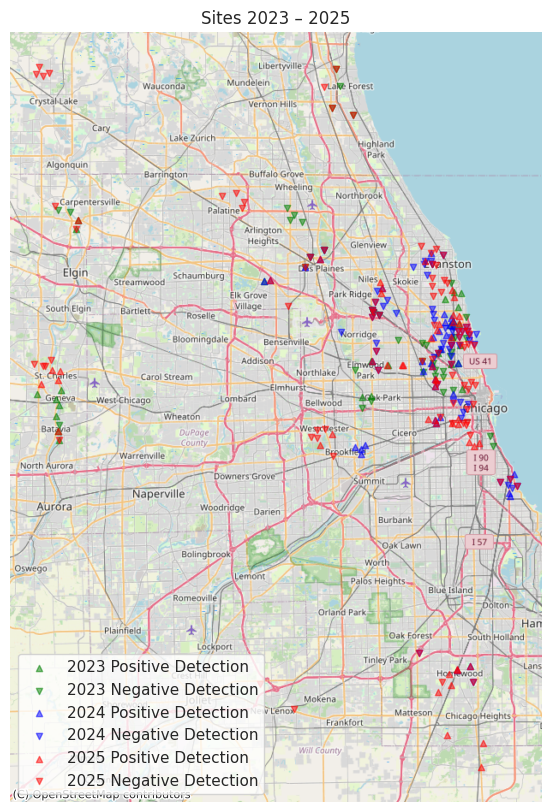

In [8]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

# Bounding box around Chicago
lat_min, lat_max = 41.6, 42.1
lon_min, lon_max = -88.0, -87.4

# Convert to GeoDataFrames
gdf_2023 = gpd.GeoDataFrame(
    obs_geo_23,
    geometry=gpd.points_from_xy(obs_geo_23['Longitude'], obs_geo_23['Latitude']),
    crs="EPSG:4326"
)

gdf_2024 = gpd.GeoDataFrame(
    obs_geo_24,
    geometry=gpd.points_from_xy(obs_geo_24['Longitude'], obs_geo_24['Latitude']),
    crs="EPSG:4326"
)

gdf_2025 = gpd.GeoDataFrame(
    obs_geo_25,
    geometry=gpd.points_from_xy(obs_geo_25['Longitude'], obs_geo_25['Latitude']),
    crs="EPSG:4326"
)

# Convert to Web Mercator for basemap tiles
gdf_2023 = gdf_2023.to_crs(epsg=3857)
gdf_2024 = gdf_2024.to_crs(epsg=3857)
gdf_2025 = gdf_2025.to_crs(epsg=3857)


# Plot
fig, ax = plt.subplots(figsize=(10,10))

# Define colors for each year
year_colors = {
    "2023": "green",
    "2024": "blue",
    "2025": "red"
}

# Process and plot for each year
for year_label, gdf_year in {"2023": gdf_2023, "2024": gdf_2024, "2025": gdf_2025}.items():
    color = year_colors[year_label]

    # Determine positive observations (any 1 in columns A, B, or C)
    positive_obs_mask = (gdf_year['A'] == 1) | (gdf_year['B'] == 1) | (gdf_year['C'] == 1)

    # Plot positive observations with '+' marker
    if not gdf_year[positive_obs_mask].empty:
        gdf_year[positive_obs_mask].plot(
            ax=ax, color=color, markersize=20, alpha=0.5, label=f"{year_label} Positive Detection", marker='^'
        )

    # Plot negative observations with '-' marker
    if not gdf_year[~positive_obs_mask].empty:
        gdf_year[~positive_obs_mask].plot(
            ax=ax, color=color, markersize=20, alpha=0.5, label=f"{year_label} Negative Detection", marker='v'
        )

# Add basemap
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.legend()
ax.set_axis_off()
plt.title("Sites 2023 – 2025")

plt.show()

## Fit a biolith occupancy model
Builds a minimal (no covariates) occupancy model for each year


In [9]:
# add output of analysis for all 3 years here
minimal_fits = []

obs_dfs = [obs_23, obs_24, obs_25]

# create empty coverate arrays
obs_covs = [
    np.zeros((obs_df.shape[0], obs_df.shape[1], 0), dtype=float)
    for obs_df in obs_dfs
]
dfs_for_fit = zip(years, obs_dfs, obs_covs)
for year, obs_df, obs_covs in dfs_for_fit:
  print('')
  print('--------', year, '--------')
  minimal_fit = fit(
      occu,
      # Empty site covariate frame => intercept-only occupancy model
      site_covs=pd.DataFrame(index=obs_df.index),
      obs_covs=obs_covs,
      obs=obs_df,
      num_samples=NUM_SAMPLES,
      num_warmup=NUM_WARMUP,
      num_chains=NUM_CHAINS,
      random_seed=RANDOM_SEED,
  )
  # Print a quick summary
  minimal_fit.mcmc.print_summary()
  minimal_fits.append(minimal_fit)

minimal_fit_23, minimal_fit_24, minimal_fit_25 = minimal_fits


-------- 2023 --------


sample: 100%|██████████| 1000/1000 [00:00<00:00, 1483.38it/s, 1 steps of size 8.48e-01. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha[0]      0.44      0.26      0.44      0.05      0.86   1027.70      1.00
   beta[0]     -0.24      0.25     -0.24     -0.60      0.21   1439.67      1.00

Number of divergences: 0

-------- 2024 --------


sample: 100%|██████████| 1000/1000 [00:00<00:00, 1425.05it/s, 3 steps of size 8.95e-01. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha[0]      0.07      0.22      0.07     -0.29      0.44   1189.34      1.00
   beta[0]     -0.23      0.23     -0.23     -0.56      0.20   1108.88      1.00

Number of divergences: 0

-------- 2025 --------


sample: 100%|██████████| 1000/1000 [00:00<00:00, 1460.67it/s, 1 steps of size 9.38e-01. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha[0]      0.52      0.20      0.52      0.20      0.83   1239.33      1.00
   beta[0]     -0.45      0.18     -0.45     -0.73     -0.15   1112.64      1.00

Number of divergences: 0


## Explore fitted model values

First I plotted the output of the model to see how the occupancy and detection probability posteriors varied over timne. While there is some variance, I didn't see a clear trend, and  didn't see anything confirming or contradicting my hypothosis that more sites would lead to better data.

The histograms in the next cell are generated from what's called a Markov Chain Monte Carlo (MCMC) simulation. Think of MCMC as repeatedly 'sampling' from the possible values for occupancy and detection probability based on our data and model assumptions. Each bar in the histogram shows how often a particular range of probability values was sampled. The shape of these histograms gives us a visual representation of the *posterior distribution* — our updated belief about what these probabilities could be, after incorporating the data. So, these plots essentially summarize the range of plausible values for site occupancy and detection probability that the model found.

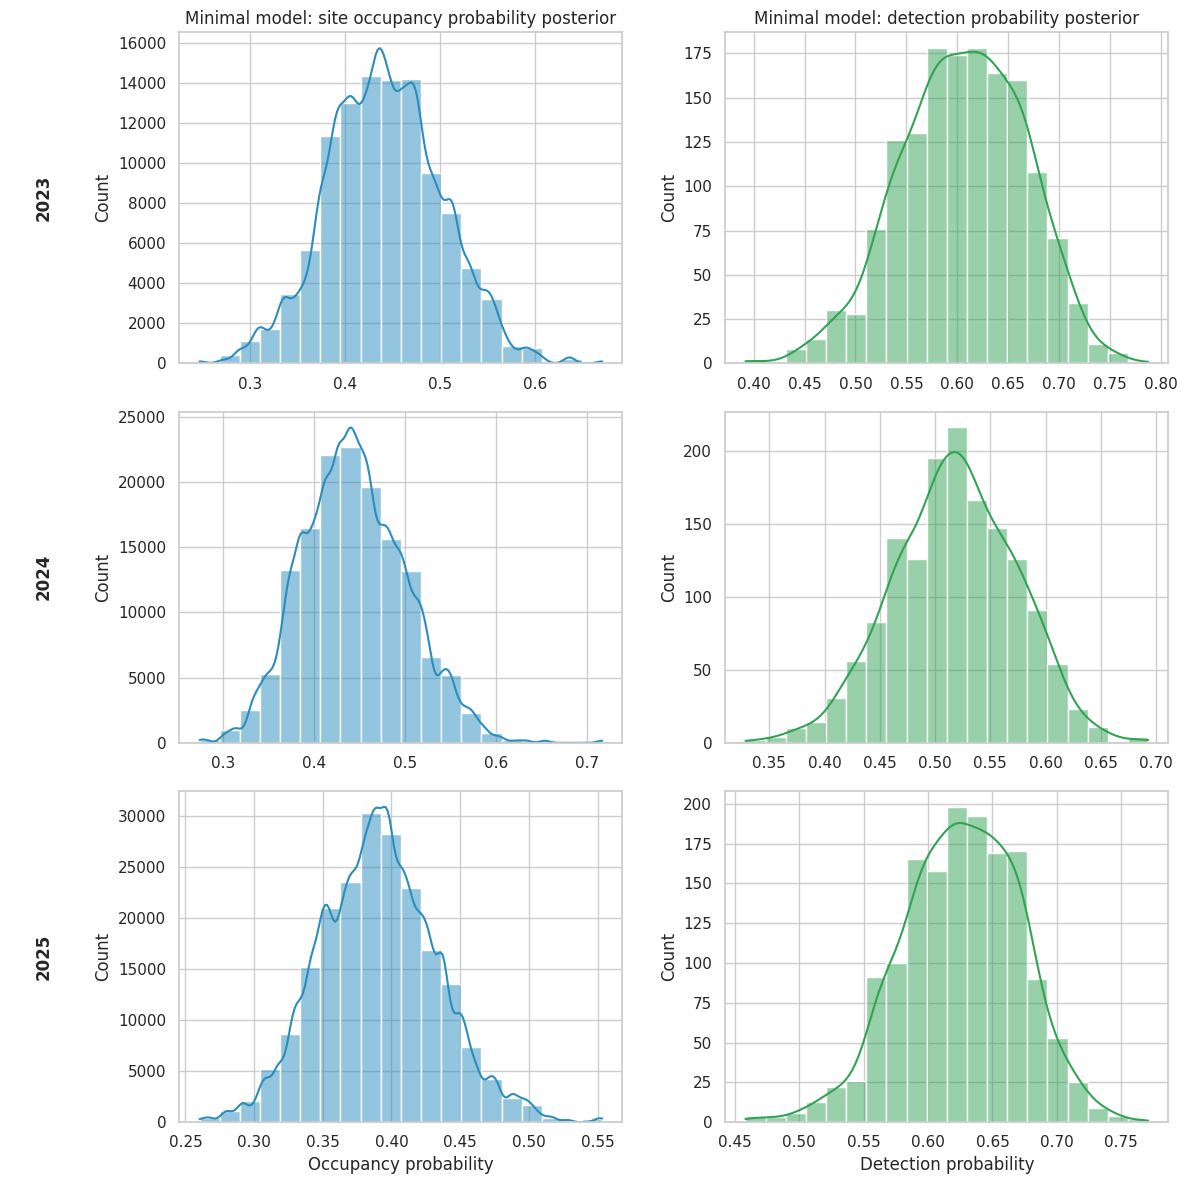

In [10]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 12))

# 3 rows, 3 columns (first column is narrow for labels)
gs = GridSpec(3, 3, figure=fig, width_ratios=[0.15, 1, 1])

row_labels = ["2023", "2024", "2025"]

# Data for plotting
psi_samples = [
    minimal_fit_23.samples["psi"].reshape(-1),
    minimal_fit_24.samples["psi"].reshape(-1),
    minimal_fit_25.samples["psi"].reshape(-1),
]
det_samples = [
    sigmoid(minimal_fit_23.samples["cov_det_0"].reshape(-1)),
    sigmoid(minimal_fit_24.samples["cov_det_0"].reshape(-1)),
    sigmoid(minimal_fit_25.samples["cov_det_0"].reshape(-1)),
]

for r in range(3):
    # Row label axis
    ax_label = fig.add_subplot(gs[r, 0])
    ax_label.axis("off")
    ax_label.text(
        0.5, 0.5,
        row_labels[r],
        rotation=90,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    # Occupancy probability histogram
    ax_psi = fig.add_subplot(gs[r, 1])
    sns.histplot(psi_samples[r], bins=20, kde=True, ax=ax_psi, color="#2b8cbe")
    if r == 0: # Only add title to the first row
        ax_psi.set_title("Minimal model: site occupancy probability posterior")
    if r == 2: # Only add xlabel to the last row
        ax_psi.set_xlabel("Occupancy probability")
    else:
        ax_psi.set_xlabel("") # Remove xlabel for middle rows

    # Detection probability histogram
    ax_det = fig.add_subplot(gs[r, 2])
    sns.histplot(det_samples[r], bins=20, kde=True, ax=ax_det, color="#31a354")
    if r == 0: # Only add title to the first row
        ax_det.set_title("Minimal model: detection probability posterior")
    if r == 2: # Only add xlabel to the last row
        ax_det.set_xlabel("Detection probability")
    else:
        ax_det.set_xlabel("") # Remove xlabel for middle rows


fig.tight_layout()
plt.show()


The plots below show the same data as the histograms, but as box plots, plotted against the number of sites visitted. Close visual inspection does show improvement by the last year, as the probability narrows, showing more confidence, for 2025. However, I still was hoping to find a more clear visualization.

First, get some summary values.

In [11]:
n_sites_23 = minimal_fit_23.samples["psi"].shape[1]
n_sites_24 = minimal_fit_24.samples["psi"].shape[1]
n_sites_25 = minimal_fit_25.samples["psi"].shape[1]

n_sites_values = [n_sites_23, n_sites_24, n_sites_25]

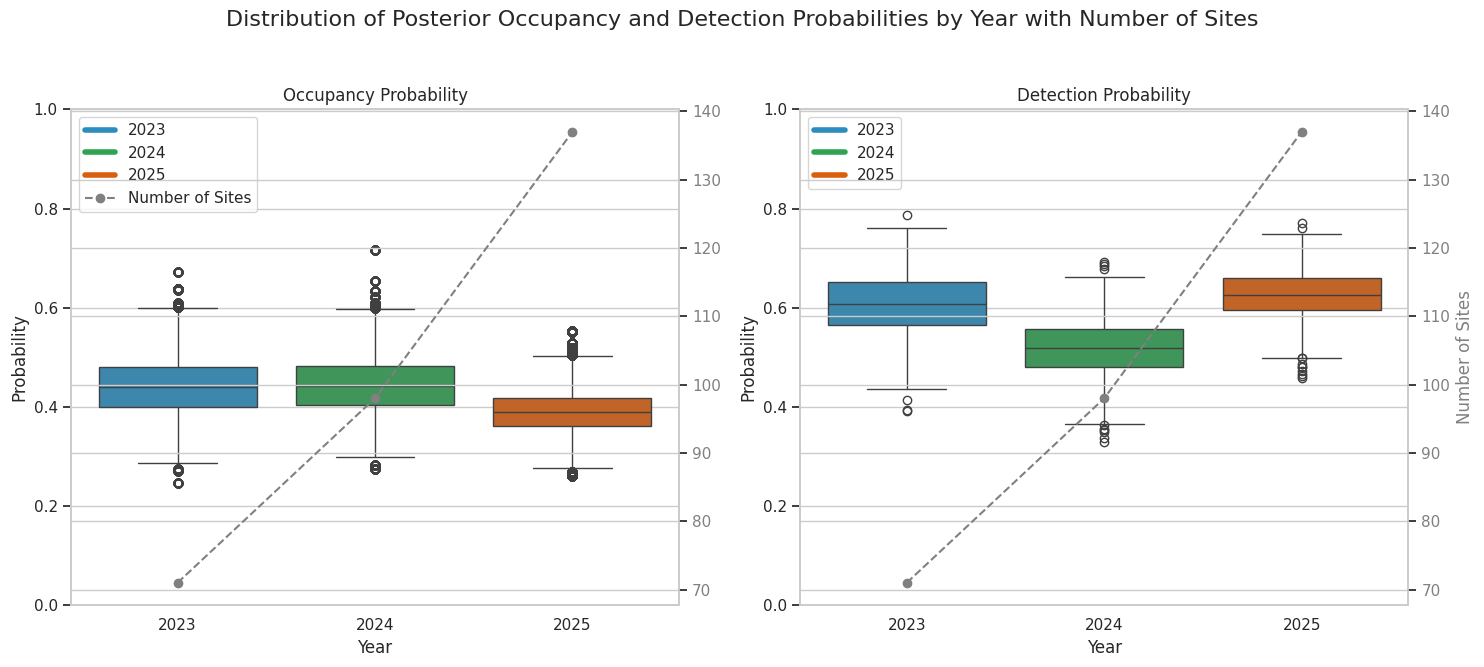

In [12]:
# Prepare data for seaborn boxplots
all_psi_samples = np.concatenate([psi_samples[0], psi_samples[1], psi_samples[2]])
all_det_samples = np.concatenate([det_samples[0], det_samples[1], det_samples[2]])
all_years_psi = ['2023']*len(psi_samples[0]) + ['2024']*len(psi_samples[1]) + ['2025']*len(psi_samples[2])
all_years_det = ['2023']*len(det_samples[0]) + ['2024']*len(det_samples[1]) + ['2025']*len(det_samples[2])

psi_df = pd.DataFrame({'Probability': all_psi_samples, 'Year': all_years_psi})
det_df = pd.DataFrame({'Probability': all_det_samples, 'Year': all_years_det})

# Define colors (matching plotly output)
colors = {'2023': '#2b8cbe', '2024': '#31a354', '2025': '#d95f0e'}
site_line_color = 'gray'

# Create the figure and two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Distribution of Posterior Occupancy and Detection Probabilities by Year with Number of Sites", fontsize=16)

# --- Occupancy Probability Subplot (Left Column) ---
ax1 = axes[0]
ax1_secondary = ax1.twinx() # Create a secondary y-axis

# Plot box plots for Occupancy Probability
sns.boxplot(x='Year', y='Probability', data=psi_df, ax=ax1,
            palette=colors, showfliers=True, hue='Year',
            legend=False) # Manual legend creation below

# Plot Number of Sites on the secondary y-axis
ax1_secondary.plot(years, n_sites_values, color=site_line_color, linestyle='--', marker='o', label='Number of Sites')

# Set titles and labels for the first subplot
ax1.set_title("Occupancy Probability")
ax1.set_xlabel("Year")
ax1.set_ylabel("Probability")
# ax1_secondary.set_ylabel("Number of Sites", color=site_line_color)
ax1_secondary.tick_params(axis='y', labelcolor=site_line_color) # Set color for secondary y-axis labels
ax1.set_ylim(0, 1) # Probabilities are between 0 and 1

# Create custom legend handles for the box plots for each year
box_legend_handles_1 = [plt.Line2D([0], [0], color=colors[year], lw=4, label=year) for year in years]
# Get the handle for 'Number of Sites' from the secondary axis plot
site_legend_handle_1, site_legend_label_1 = ax1_secondary.get_legend_handles_labels()[0], ax1_secondary.get_legend_handles_labels()[1][0]
# Combine and display legend for ax1
ax1.legend(handles=box_legend_handles_1 + site_legend_handle_1, labels=[h.get_label() for h in box_legend_handles_1] + [site_legend_label_1], loc='upper left')


# --- Detection Probability Subplot (Right Column) ---
ax2 = axes[1]
ax2_secondary = ax2.twinx() # Create a secondary y-axis

# Plot box plots for Detection Probability
sns.boxplot(x='Year',
            y='Probability',
            data=det_df, ax=ax2,
            palette=colors, showfliers=True, hue='Year',
            legend=False) # Manual legend creation below

# Plot Number of Sites on the secondary y-axis (no label here to avoid duplicate legend entry for 'Number of Sites')
ax2_secondary.plot(years, n_sites_values, color=site_line_color, linestyle='--', marker='o')

# Set titles and labels for the second subplot
ax2.set_title("Detection Probability")
ax2.set_xlabel("Year")
# ax2.set_ylabel("Probability")
ax2_secondary.set_ylabel("Number of Sites", color=site_line_color)
ax2_secondary.tick_params(axis='y', labelcolor=site_line_color) # Set color for secondary y-axis labels
ax2.set_ylim(0, 1) # Probabilities are between 0 and 1

# Create custom legend handles for the box plots for each year (only year legends for ax2)
box_legend_handles_2 = [plt.Line2D([0], [0], color=colors[year], lw=4, label=year) for year in years]
ax2.legend(handles=box_legend_handles_2, labels=[h.get_label() for h in box_legend_handles_2], loc='upper left')

# Final layout adjustments
fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for the suptitle
plt.show()

Summarizing the box plots and plotting the summary stats shows that as the number of sites increases, the width of the distribution quartiles decrecreases, illustrating that the model became more confident each year. This does indeed show that for our survey, the more sites the better!

In [13]:
def calculate_boxplot_stats(samples):
    q1 = np.percentile(samples, 25)
    median = np.percentile(samples, 50)
    q3 = np.percentile(samples, 75)
    iqr = q3 - q1

    # Calculate whisker bounds (excluding outliers based on 1.5*IQR rule)
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    lower_whisker = samples[samples >= lower_fence].min()
    upper_whisker = samples[samples <= upper_fence].max()

    return q1, median, q3, lower_whisker, upper_whisker

# Prepare data for display
all_stats = []

for i, year in enumerate(years):
    # Occupancy Probability (psi)
    psi_q1, psi_median, psi_q3, psi_lw, psi_uw = calculate_boxplot_stats(psi_samples[i])
    all_stats.append({
        'Year': year,
        'Parameter': 'psi',
        'Q1': psi_q1,
        'Median': psi_median,
        'Q3': psi_q3,
        'lw': psi_lw,
        'uw': psi_uw,
        'quartile_range': psi_q3 - psi_q1,
        'whisker_range': psi_uw - psi_lw,
    })

    # Detection Probability (det)
    det_q1, det_median, det_q3, det_lw, det_uw = calculate_boxplot_stats(det_samples[i])
    all_stats.append({
        'Year': year,
        'Parameter': 'det',
        'Q1': det_q1,
        'Median': det_median,
        'Q3': det_q3,
        'lw': det_lw,
        'uw': det_uw,
        'quartile_range': det_q3 - det_q1,
        'whisker_range': det_uw - det_lw,
    })

stats_df = pd.DataFrame(all_stats)
display(stats_df)

,Year,Parameter,Q1,Median,Q3,lw,uw,quartile_range,whisker_range
0,2023,psi,0.400593,0.440121,0.480867,0.28643665,0.5989877,0.080273,0.31255105
1,2023,det,0.564500,0.607812,0.651168,0.435309,0.76168,0.086667,0.326371
2,2024,psi,0.404512,0.441667,0.482422,0.29929087,0.5975831,0.077909,0.29829225
3,2024,det,0.479844,0.518539,0.556649,0.365286,0.662687,0.076805,0.297401
4,2025,psi,0.361663,0.389910,0.418893,0.27689338,0.503387,0.057230,0.2264936
5,2025,det,0.595313,0.626590,0.659332,0.499377,0.747722,0.064019,0.248346


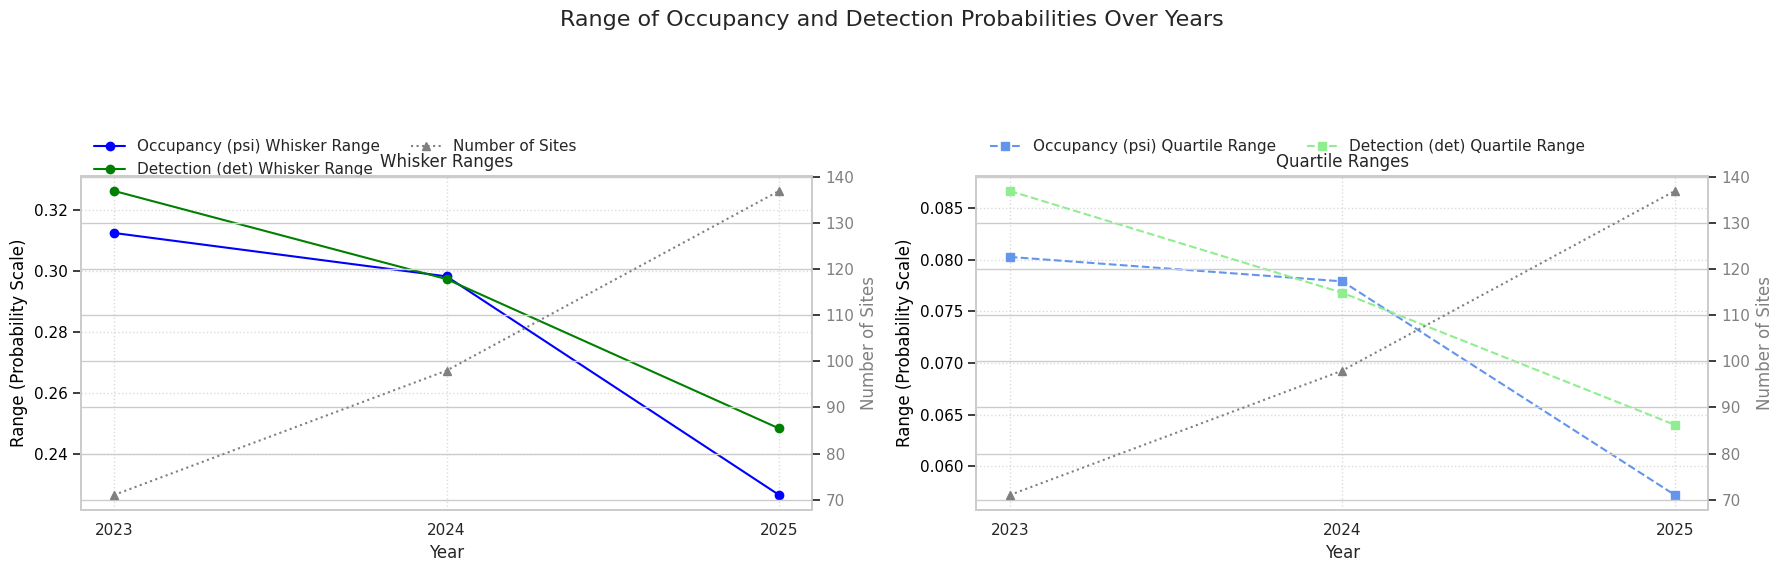

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate stats for Occupancy and Detection
occupancy_whisker_range = stats_df[stats_df['Parameter'] == 'psi'].set_index('Year')['whisker_range']
detection_whisker_range = stats_df[stats_df['Parameter'] == 'det'].set_index('Year')['whisker_range']

occupancy_quartile_range = stats_df[stats_df['Parameter'] == 'psi'].set_index('Year')['quartile_range']
detection_quartile_range = stats_df[stats_df['Parameter'] == 'det'].set_index('Year')['quartile_range']

fig, (ax1, ax2_quartile) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Range of Occupancy and Detection Probabilities Over Years', fontsize=16)

# --- Left Subplot: Whisker Ranges ---
# Plot whisker ranges on the primary y-axis (ax1)
ax1.plot(occupancy_whisker_range.index, occupancy_whisker_range, marker='o', linestyle='-', color='blue', label='Occupancy (psi) Whisker Range')
ax1.plot(detection_whisker_range.index, detection_whisker_range, marker='o', linestyle='-', color='green', label='Detection (det) Whisker Range')

ax1.set_title('Whisker Ranges')
ax1.set_xlabel('Year')
ax1.set_ylabel('Range (Probability Scale)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle=':', alpha=0.7)

# Create a secondary y-axis for the number of sites on ax1
ax1_twin = ax1.twinx()
ax1_twin.plot(years, n_sites_values, marker='^', linestyle=':', color='gray', label='Number of Sites')
ax1_twin.set_ylabel('Number of Sites', color='gray')
ax1_twin.tick_params(axis='y', labelcolor='gray')

# Add legend for ax1
handles1, labels1 = ax1.get_legend_handles_labels()
handles1_twin, labels1_twin = ax1_twin.get_legend_handles_labels()
ax1.legend(handles1 + handles1_twin, labels1 + labels1_twin, loc='upper left', bbox_to_anchor=(0, 1.15), ncol=2, frameon=False)

# --- Right Subplot: Quartile Ranges ---
# Plot quartile ranges on the primary y-axis (ax2_quartile)
ax2_quartile.plot(occupancy_quartile_range.index, occupancy_quartile_range, marker='s', linestyle='--', color='cornflowerblue', label='Occupancy (psi) Quartile Range')
ax2_quartile.plot(detection_quartile_range.index, detection_quartile_range, marker='s', linestyle='--', color='lightgreen', label='Detection (det) Quartile Range')

ax2_quartile.set_title('Quartile Ranges')
ax2_quartile.set_xlabel('Year')
ax2_quartile.set_ylabel('Range (Probability Scale)', color='black')
ax2_quartile.tick_params(axis='y', labelcolor='black')
ax2_quartile.grid(True, linestyle=':', alpha=0.7)

# Create a secondary y-axis for the number of sites on ax2_quartile
ax2_twin = ax2_quartile.twinx()
ax2_twin.plot(years, n_sites_values, marker='^', linestyle=':', color='gray', label='Number of Sites') # Re-add for consistency, label already in ax1
ax2_twin.set_ylabel('Number of Sites', color='gray')
ax2_twin.tick_params(axis='y', labelcolor='gray')

# Add legend for ax2_quartile (only quartile ranges, N_sites is already in ax1 legend)
handles2_q, labels2_q = ax2_quartile.get_legend_handles_labels()
ax2_quartile.legend(handles2_q, labels2_q, loc='upper left', bbox_to_anchor=(0, 1.15), ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent labels/title from overlapping
plt.show()